# 🎬 IMDB Movie Data Analysis — Complete Project

> **What we're building:** A complete data analysis of 1000 movies — exploring ratings, genres, revenue, and trends with charts.

This notebook walks through the **entire data analytics workflow** on a real-sized dataset. Every code line is explained. Run cells one by one with **Shift + Enter**.

### What you'll learn
1. How to load and explore data
2. How to clean missing values
3. How to answer real questions with Pandas
4. How to visualize findings clearly
5. How to write conclusions from data

---

## Step 1 — Import the Libraries We'll Use

Before we can do anything, we need to bring in the libraries (toolboxes) we'll use throughout this notebook.

In [5]:
# pandas — for working with tables of data (our main tool)
import pandas as pd

# numpy — for numerical operations (works behind the scenes)
import numpy as np

# matplotlib — the foundation for making charts
import matplotlib.pyplot as plt

# seaborn — sits on top of matplotlib, makes prettier charts in one line
import seaborn as sns

# Configure the look of our charts globally
sns.set_theme(style="whitegrid")          # white background with light grid lines
plt.rcParams["figure.figsize"] = (10, 6)  # default chart size: 10 inches wide, 6 tall
plt.rcParams["font.size"] = 11            # default text size

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


**What just happened?**
- `import pandas as pd` — brings in pandas and lets us refer to it as `pd` for short
- `import numpy as np` — same thing for numpy → `np`
- `import matplotlib.pyplot as plt` — brings in the plotting module → `plt`
- `import seaborn as sns` — brings in seaborn → `sns`

These shortcuts (`pd`, `np`, `plt`, `sns`) are universal conventions — every Python data analyst uses these exact names.

---

## Step 2 — Load the Dataset

Now we read our CSV file (the movie data) and turn it into a DataFrame (a table inside Python).

In [6]:
# Read the CSV file and store it in a variable called 'df' (short for "data frame")
df = pd.read_csv("../data/imdb_movies.csv")

# Confirm it loaded
print(f"✅ Data loaded — {len(df)} movies in the dataset.")

✅ Data loaded — 1000 movies in the dataset.


**Line by line:**
- `pd.read_csv("../data/imdb_movies.csv")` — open the CSV file. The `..` means "go up one folder", because the notebook is in `notebooks/` and the data is in `data/`
- `df = ...` — store the result in a variable named `df`
- `len(df)` — gives us the number of rows

---

## Step 3 — First Look at the Data (The 4 Essential Checks)

On any new dataset, **always** do these four checks in order. They take 10 seconds and tell you what you're working with.

### Check 1 — Shape (how big is the data?)

In [7]:
# .shape returns a pair: (number of rows, number of columns)
# Notice there are no parentheses — shape is an attribute, not a method
print("Shape of our data:", df.shape)
print(f"  → {df.shape[0]} rows (movies)")
print(f"  → {df.shape[1]} columns (info per movie)")

Shape of our data: (1000, 9)
  → 1000 rows (movies)
  → 9 columns (info per movie)


### Check 2 — Head (what do the first few rows look like?)

In [8]:
# .head() shows the first 5 rows by default
# You can pass a number to see more: df.head(10) shows 10
df.head()

,title,year,genre,director,runtime_minutes,rating,votes,budget_millions,revenue_millions
0,A Hunter for Witness,1990,Sci-Fi,H. Miller,112.0,4.6,22840,28.5,22.7
1,Broken Throne,1990,Action,P. Singh,111.0,4.6,7164,20.3,13.0
2,Golden War: Whisper,1990,Romance,O. Hassan,NaN,6.7,1077675,13.7,29.1
3,Hidden Code,1990,Comedy,V. Petrov,98.0,5.5,10845,1.9,0.8
4,Lost Hunter,1990,Horror,Y. Yamamoto,137.0,5.2,91197,13.9,15.5


Look at the column names — these are the pieces of information we have for each movie:
- **title** — name of the movie
- **year** — release year
- **genre** — Action, Drama, Comedy, etc.
- **director** — who directed it
- **runtime_minutes** — how long the movie is
- **rating** — IMDB-style rating (1 to 10)
- **votes** — how many people rated it
- **budget_millions** — production budget in million $
- **revenue_millions** — how much money it made in million $

### Check 3 — Info (data types and missing values)

In [9]:
# .info() shows the column types and how many non-missing values each has
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             1000 non-null   str    
 1   year              1000 non-null   int64  
 2   genre             1000 non-null   str    
 3   director          1000 non-null   str    
 4   runtime_minutes   971 non-null    float64
 5   rating            1000 non-null   float64
 6   votes             1000 non-null   int64  
 7   budget_millions   967 non-null    float64
 8   revenue_millions  1000 non-null   float64
dtypes: float64(4), int64(2), str(3)
memory usage: 101.1 KB


**What to look for:**
- The `Dtype` column shows each column's type — `object` means text, `int64`/`float64` are numbers
- The `Non-Null Count` column tells us missing values. If it's less than the total rows, there are missing values

### Check 4 — Describe (summary statistics)

In [10]:
# .describe() gives summary stats for all NUMBER columns
df.describe()

,year,runtime_minutes,rating,votes,budget_millions,revenue_millions
count,1000.000000,971.000000,1000.000000,1.000000e+03,967.000000,1000.000000
mean,2009.837000,111.580844,6.317400,1.969407e+05,31.877973,53.634500
std,9.853401,18.477638,1.250088,3.590787e+05,46.356691,101.234833
min,1990.000000,70.000000,2.200000,1.850000e+02,0.700000,0.500000
25%,2002.000000,98.500000,5.500000,2.169375e+04,8.200000,8.775000
50%,2011.000000,110.000000,6.300000,6.654700e+04,17.200000,22.300000
75%,2018.000000,124.000000,7.200000,1.926205e+05,34.200000,54.100000
max,2024.000000,175.000000,10.000000,2.000000e+06,350.000000,1069.000000


Read this table top to bottom for each column:
- **count** — how many non-missing values
- **mean** — average
- **std** — standard deviation (spread)
- **min / max** — smallest and biggest values
- **25% / 50% / 75%** — percentiles (50% = median)

Already we can see interesting things:
- Average rating is around **6.0–6.5**
- Some movies have over **1 million votes**, some have just a few hundred
- Revenue is highly skewed — most movies make little, a few make hundreds of millions

---

## Step 4 — Clean the Data (Handle Missing Values)

Real data always has missing values. We need to deal with them before analysis.

### Find missing values

In [11]:
# isnull() converts each cell to True (missing) or False (not missing)
# .sum() counts how many True values per column
df.isnull().sum()

title                0
year                 0
genre                0
director             0
runtime_minutes     29
rating               0
votes                0
budget_millions     33
revenue_millions     0
dtype: int64

We have some missing values in `runtime_minutes` and `budget_millions`. Two strategies:
1. **Drop** the rows that have missing values
2. **Fill** the missing values with something sensible (mean, median, or 0)

Since `runtime_minutes` and `budget_millions` are numeric, we'll fill them with the **median** of each column. The median is safer than the mean because it isn't pulled by outliers.

In [12]:
# Fill missing runtime with the median runtime
median_runtime = df["runtime_minutes"].median()
df["runtime_minutes"] = df["runtime_minutes"].fillna(median_runtime)
print(f"Filled missing runtime with median: {median_runtime} minutes")

# Fill missing budget with the median budget
median_budget = df["budget_millions"].median()
df["budget_millions"] = df["budget_millions"].fillna(median_budget)
print(f"Filled missing budget with median: ${median_budget} million")

Filled missing runtime with median: 110.0 minutes
Filled missing budget with median: $17.2 million


**Line by line:**
- `df["runtime_minutes"].median()` — calculates the median of the runtime column
- `df["runtime_minutes"].fillna(value)` — replaces missing values with `value`
- We assign the result back to the column (`df["runtime_minutes"] = ...`) to save the change

In [13]:
# Verify — no more missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
title               0
year                0
genre               0
director            0
runtime_minutes     0
rating              0
votes               0
budget_millions     0
revenue_millions    0
dtype: int64


---

## Step 5 — Analysis Question 1: Top 10 Highest-Rated Movies

Let's find the best-rated movies — but we need to be careful. A movie rated once at 10.0 by one person isn't really a "top movie". So we'll require **at least 10,000 votes** to be considered.

In [14]:
# Step 1 — Filter: keep only movies with at least 10,000 votes
# Read this as: "give me df where votes is greater than or equal to 10000"
popular = df[df["votes"] >= 10000]

# Step 2 — Sort by rating (highest first) and pick top 10
top_10 = popular.sort_values("rating", ascending=False).head(10)

# Show only the columns we care about
top_10[["title", "year", "genre", "rating", "votes"]]

,title,year,genre,rating,votes
184,The Golden Forest,1999,Comedy,10.0,76566
862,Throne of Throne,2021,Action,9.8,126435
560,Shadow Garden,2013,Comedy,9.5,10532
807,Iron Hunter: Throne,2020,Comedy,9.4,1866483
891,The Endless Garden,2022,Romance,9.3,68847
74,Broken Dawn: Garden,1994,Romance,9.3,488847
799,Final Star,2020,Sci-Fi,9.3,57444
764,Final Code: Sky,2019,Sci-Fi,9.3,21695
645,The Stolen Promise,2015,Thriller,9.2,304492
699,Empty Truth: Witness,2017,Comedy,9.2,274237


**Breaking down `popular.sort_values("rating", ascending=False).head(10)`:**
- `.sort_values("rating", ascending=False)` — sort by rating, biggest first (descending)
- `.head(10)` — keep only the top 10 rows after sorting

### 📊 Visualize the top 10

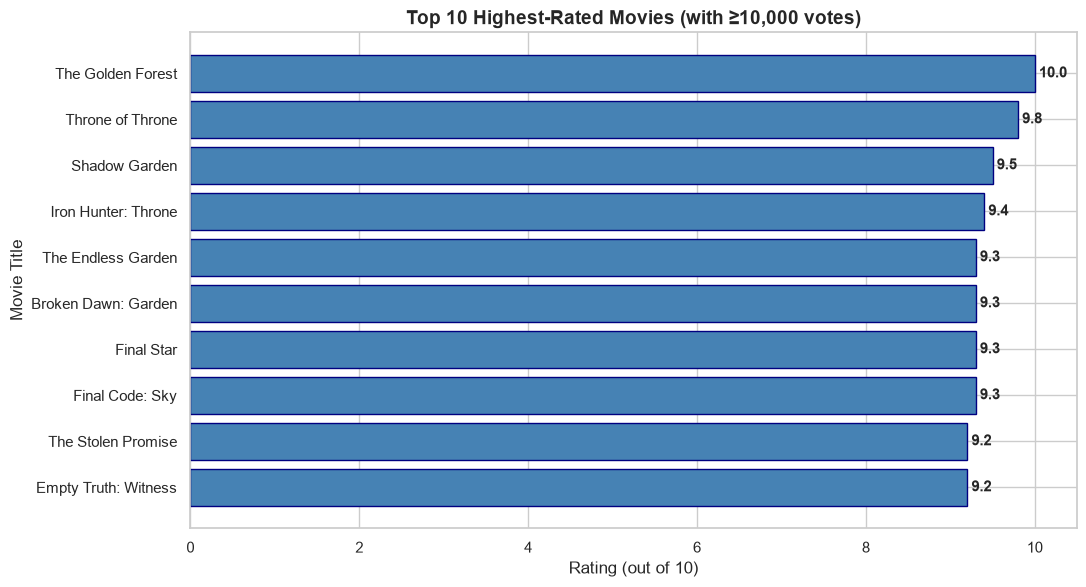

In [15]:
# Make the figure (chart area)
plt.figure(figsize=(11, 6))

# Make a horizontal bar chart — title on the y-axis, rating on x-axis
# A horizontal bar chart is better when category names are long
plt.barh(top_10["title"], top_10["rating"], color="steelblue", edgecolor="navy")

# Add labels and title
plt.title("Top 10 Highest-Rated Movies (with ≥10,000 votes)",
          fontsize=14, fontweight="bold")
plt.xlabel("Rating (out of 10)")
plt.ylabel("Movie Title")

# Reverse the y-axis so the highest is at the top
plt.gca().invert_yaxis()

# Show the rating value next to each bar
for index, value in enumerate(top_10["rating"]):
    plt.text(value + 0.05, index, f"{value:.1f}", va="center", fontweight="bold")

# Display the chart
plt.tight_layout()
plt.show()

**Line by line:**
- `plt.figure(figsize=(11, 6))` — create a chart that's 11 inches wide × 6 tall
- `plt.barh(x_labels, x_values, ...)` — horizontal bar chart
- `plt.gca().invert_yaxis()` — flip so #1 is at the top (otherwise it's at the bottom)
- The `for` loop adds the rating number next to each bar
- `plt.tight_layout()` — automatically adjusts spacing so nothing overlaps
- `plt.show()` — actually display the chart

---

## Step 6 — Analysis Question 2: How Many Movies in Each Genre?

In [16]:
# value_counts() counts how often each unique value appears
# It returns the result already sorted from most common to least
genre_counts = df["genre"].value_counts()

# Show the result
print(genre_counts)

genre
Action       183
Comedy       167
Drama        156
Thriller     133
Sci-Fi        92
Horror        90
Romance       79
Animation     43
Adventure     37
Mystery       20
Name: count, dtype: int64


### 📊 Visualize genre distribution

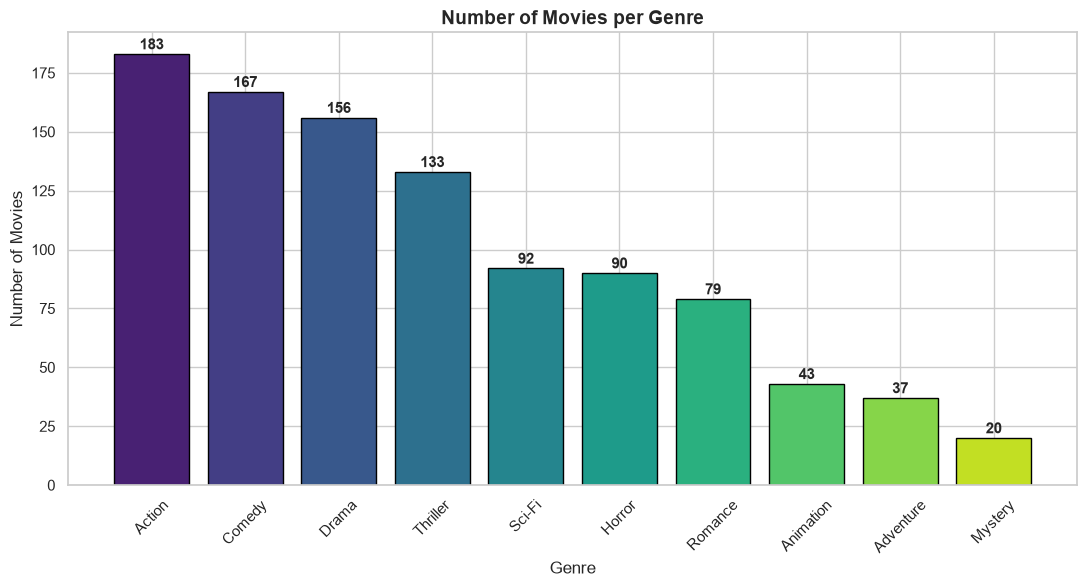

In [17]:
plt.figure(figsize=(11, 6))

# Bar chart — categories on x-axis, counts on y-axis
# Use a colour palette to give each bar a different colour
colors = sns.color_palette("viridis", n_colors=len(genre_counts))
plt.bar(genre_counts.index, genre_counts.values, color=colors, edgecolor="black")

plt.title("Number of Movies per Genre", fontsize=14, fontweight="bold")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)   # tilt x-labels 45° so they don't overlap

# Add the count number on top of each bar
for index, value in enumerate(genre_counts.values):
    plt.text(index, value + 2, str(value), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Key new bits:**
- `sns.color_palette("viridis", n_colors=N)` — gives us N nicely-spread colours
- `plt.xticks(rotation=45)` — rotates the labels so they fit
- `ha="center"` — horizontal alignment of the text on top of each bar

---

## Step 7 — Analysis Question 3: Which Genre Has the Highest Average Rating?

Here we group all movies by genre and compute the mean rating within each group.

In [18]:
# Group by genre, then take the mean of rating within each group
# Then sort to put the highest first
avg_rating_by_genre = df.groupby("genre")["rating"].mean().sort_values(ascending=False)

# Round to 2 decimal places for cleaner display
avg_rating_by_genre = avg_rating_by_genre.round(2)

print(avg_rating_by_genre)

genre
Animation    6.97
Drama        6.78
Sci-Fi       6.66
Mystery      6.63
Adventure    6.51
Thriller     6.42
Action       6.23
Comedy       6.08
Romance      5.89
Horror       5.55
Name: rating, dtype: float64


**Breaking down `df.groupby("genre")["rating"].mean()`:**
1. `df.groupby("genre")` — split the data into groups by genre
2. `["rating"]` — within each group, look at the rating column
3. `.mean()` — take the average

This is the most powerful pattern in Pandas — "X per Y" questions.

### 📊 Visualize average rating per genre

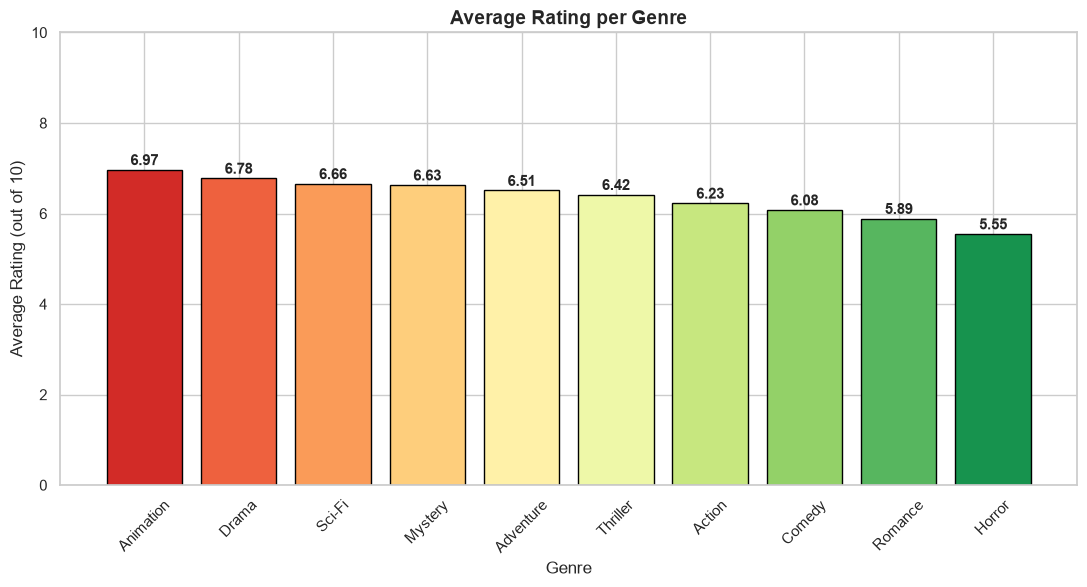

In [19]:
plt.figure(figsize=(11, 6))

# Bar chart sorted by rating
# Using a sequential colour palette — lighter for higher ratings
colors_grad = sns.color_palette("RdYlGn", n_colors=len(avg_rating_by_genre))

plt.bar(avg_rating_by_genre.index, avg_rating_by_genre.values,
        color=colors_grad, edgecolor="black")

plt.title("Average Rating per Genre", fontsize=14, fontweight="bold")
plt.xlabel("Genre")
plt.ylabel("Average Rating (out of 10)")
plt.xticks(rotation=45)
plt.ylim(0, 10)   # set y-axis from 0 to 10 since that's the rating scale

# Annotate each bar
for index, value in enumerate(avg_rating_by_genre.values):
    plt.text(index, value + 0.1, f"{value:.2f}",
             ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

---

## Step 8 — Analysis Question 4: How Many Movies Released Per Year?

This shows us trends over time — are more movies being made? Less?

In [20]:
# Count movies per year — sorted by year, not by count
movies_per_year = df["year"].value_counts().sort_index()

# Show first few years
movies_per_year.head(10)

year
1990    17
1991    15
1992    19
1993    21
1994    16
1995    18
1996    18
1997    24
1998    20
1999    24
Name: count, dtype: int64

**Why `.sort_index()` and not `.sort_values()`?**
- `.sort_values()` would sort by COUNT (most popular year first)
- `.sort_index()` sorts by the INDEX (which is the year) — what we want for a time series

### 📊 Visualize movies per year — line chart

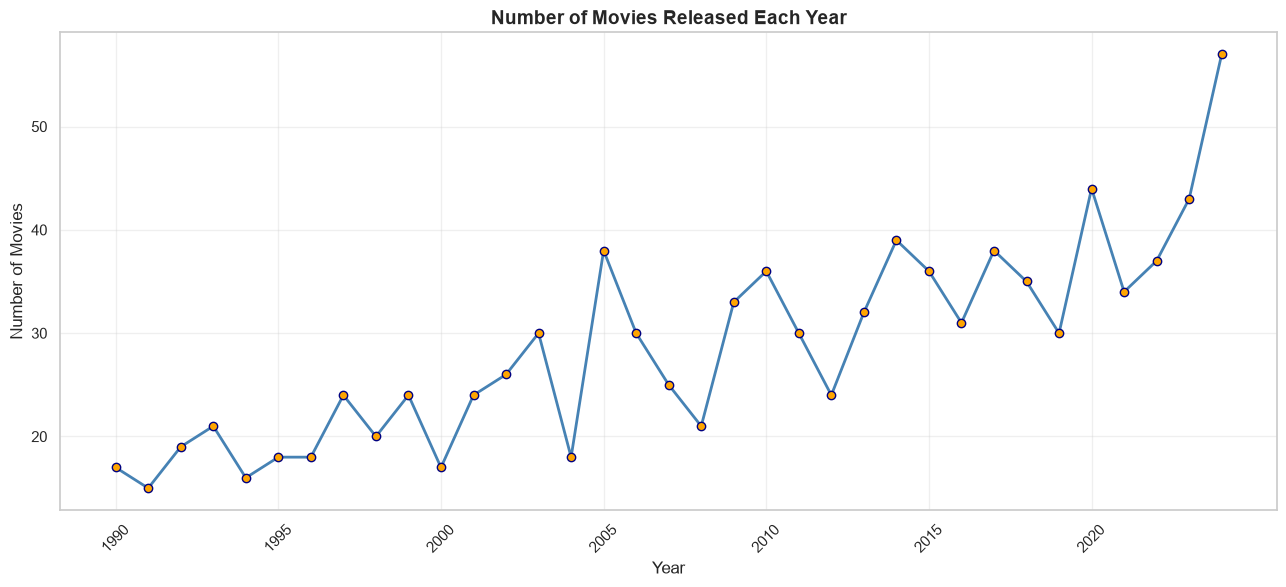

In [21]:
plt.figure(figsize=(13, 6))

# Line chart with markers at each point
plt.plot(movies_per_year.index, movies_per_year.values,
         marker="o", linewidth=2, markersize=6,
         color="steelblue", markerfacecolor="orange", markeredgecolor="navy")

plt.title("Number of Movies Released Each Year", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.grid(True, alpha=0.3)   # light grid for easier reading

# Show fewer x-tick labels (every 5 years) to avoid clutter
years_to_show = movies_per_year.index[::5]  # every 5th year
plt.xticks(years_to_show, rotation=45)

plt.tight_layout()
plt.show()

**Notice:**
- `movies_per_year.index[::5]` — `[::5]` is a slice that takes every 5th element. Same trick works for any sequence

---

## Step 9 — Analysis Question 5: Rating Distribution (What's a Typical Rating?)

A histogram is the perfect chart for showing the shape of one number.

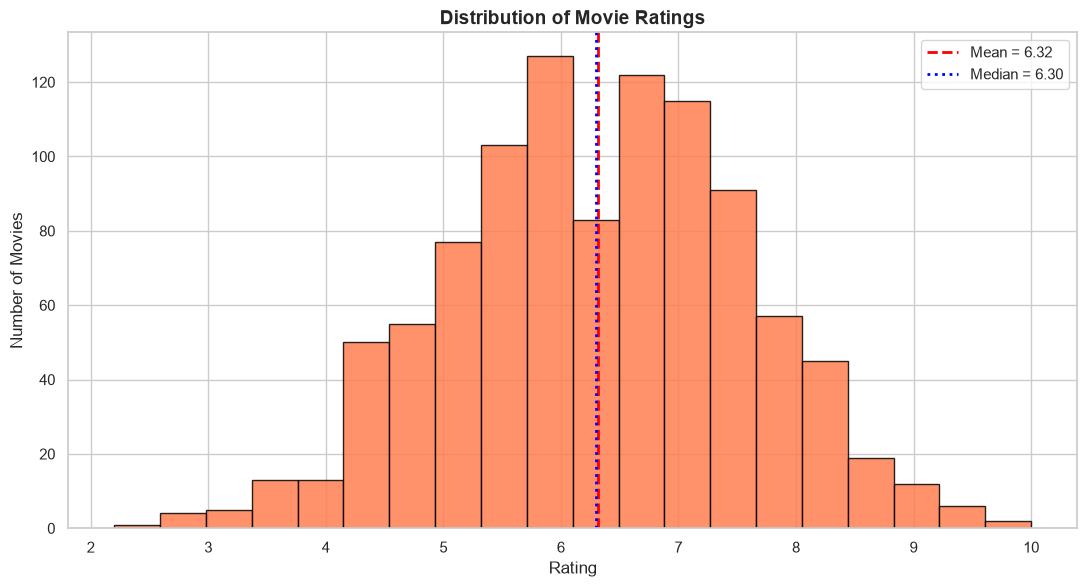

In [22]:
plt.figure(figsize=(11, 6))

# Histogram — split ratings into 20 buckets (bins)
plt.hist(df["rating"], bins=20,
         color="coral", edgecolor="black", alpha=0.85)

# Draw vertical lines at the mean and median
mean_rating = df["rating"].mean()
median_rating = df["rating"].median()

plt.axvline(mean_rating, color="red", linestyle="--", linewidth=2,
            label=f"Mean = {mean_rating:.2f}")
plt.axvline(median_rating, color="blue", linestyle=":", linewidth=2,
            label=f"Median = {median_rating:.2f}")

plt.title("Distribution of Movie Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.legend()
plt.tight_layout()
plt.show()

**What this tells us:**
- `bins=20` — divides the 1-10 rating range into 20 equal buckets
- `plt.axvline(x, ...)` — draws a vertical line at position x
- `alpha=0.85` — slight transparency on the bars
- The mean and median lines help us spot if the data is skewed

---

## Step 10 — Analysis Question 6: Top 10 Most Productive Directors

In [23]:
# Count movies per director
director_counts = df["director"].value_counts().head(10)

# Show the result
director_counts

director
E. Silva       39
D. Nakamura    35
V. Petrov      33
Y. Yamamoto    32
W. Larsen      32
I. Kowalski    31
E. Thompson    31
B. Wilson      30
M. Khan        30
A. Reddy       30
Name: count, dtype: int64

### 📊 Visualize top directors

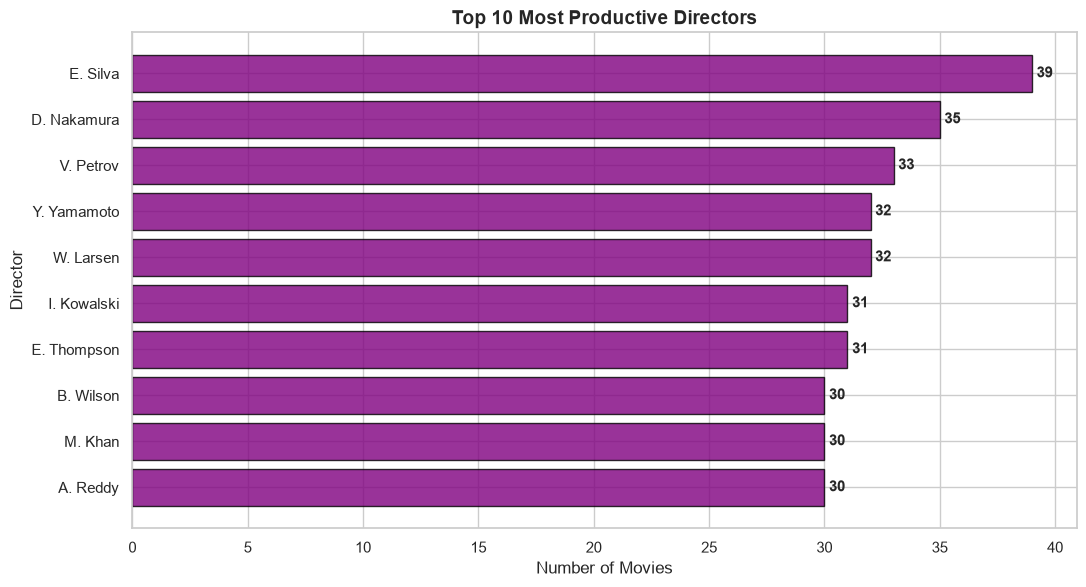

In [24]:
plt.figure(figsize=(11, 6))

# Horizontal bar chart — better for long names
plt.barh(director_counts.index, director_counts.values,
         color="purple", edgecolor="black", alpha=0.8)

plt.title("Top 10 Most Productive Directors", fontsize=14, fontweight="bold")
plt.xlabel("Number of Movies")
plt.ylabel("Director")
plt.gca().invert_yaxis()   # put #1 at the top

# Add count labels
for i, v in enumerate(director_counts.values):
    plt.text(v + 0.2, i, str(v), va="center", fontweight="bold")

plt.tight_layout()
plt.show()

---

## Step 11 — Analysis Question 7: Does Bigger Budget Mean More Revenue?

A scatter plot is the perfect chart to see if two numbers are related.

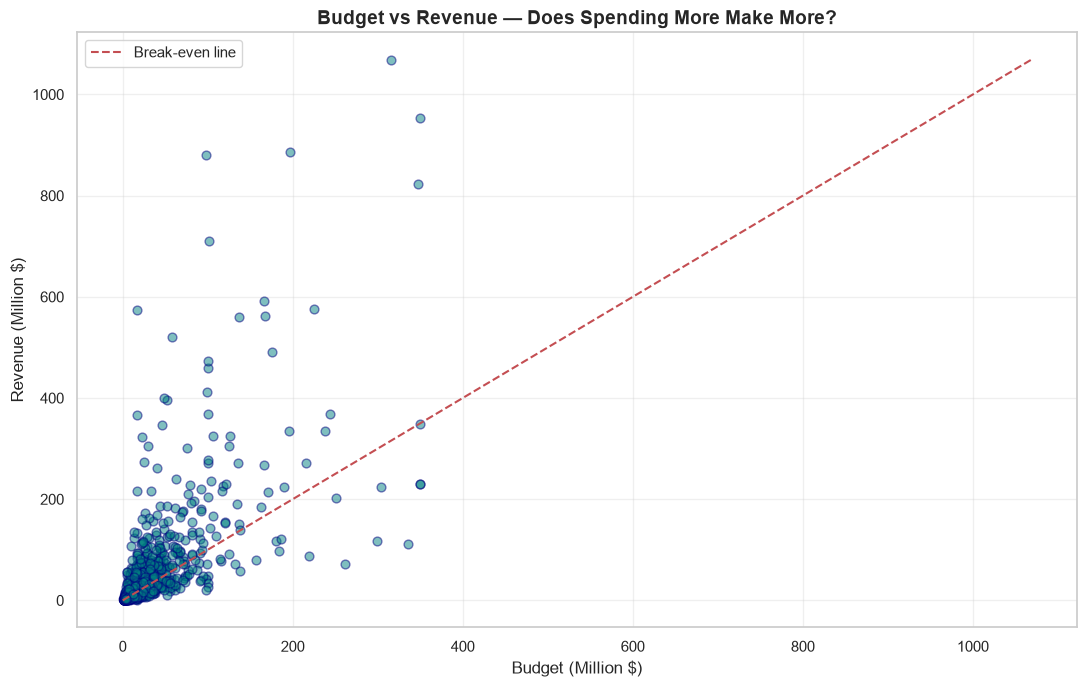

In [25]:
plt.figure(figsize=(11, 7))

# Scatter plot — every dot is one movie
# alpha=0.5 makes dots semi-transparent so overlaps are visible
plt.scatter(df["budget_millions"], df["revenue_millions"],
            alpha=0.5, s=40, color="teal", edgecolor="navy")

plt.title("Budget vs Revenue — Does Spending More Make More?",
          fontsize=14, fontweight="bold")
plt.xlabel("Budget (Million $)")
plt.ylabel("Revenue (Million $)")
plt.grid(True, alpha=0.3)

# Add a reference diagonal line: revenue = budget (break-even)
max_val = max(df["budget_millions"].max(), df["revenue_millions"].max())
plt.plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Break-even line")
plt.legend()

plt.tight_layout()
plt.show()

**Reading the chart:**
- Dots above the red line → movie made profit
- Dots below the red line → movie lost money
- Pattern going up-right → positive correlation

In [26]:
# Compute the actual correlation between budget and revenue
budget_revenue_corr = df["budget_millions"].corr(df["revenue_millions"])
print(f"Correlation between budget and revenue: {budget_revenue_corr:.3f}")

Correlation between budget and revenue: 0.674


**Reading the number:**
- Close to **+1** → strongly move together
- Close to **0** → no relationship
- Close to **−1** → move opposite ways

---

## Step 12 — Analysis Question 8: Correlation Heatmap

Let's see the correlation between **all** numeric columns at once.

In [27]:
# Select only the numeric columns we want to compare
numeric_cols = ["year", "runtime_minutes", "rating", "votes",
                "budget_millions", "revenue_millions"]

# Compute the correlation matrix — every column vs every other column
correlation_matrix = df[numeric_cols].corr()

# Show the matrix
correlation_matrix.round(2)

,year,runtime_minutes,rating,votes,budget_millions,revenue_millions
year,1.00,-0.04,-0.02,-0.01,0.02,0.01
runtime_minutes,-0.04,1.00,0.00,-0.05,0.14,0.10
rating,-0.02,0.00,1.00,0.24,0.02,0.18
votes,-0.01,-0.05,0.24,1.00,-0.02,-0.01
budget_millions,0.02,0.14,0.02,-0.02,1.00,0.67
revenue_millions,0.01,0.10,0.18,-0.01,0.67,1.00


### 📊 Visualize as a heatmap

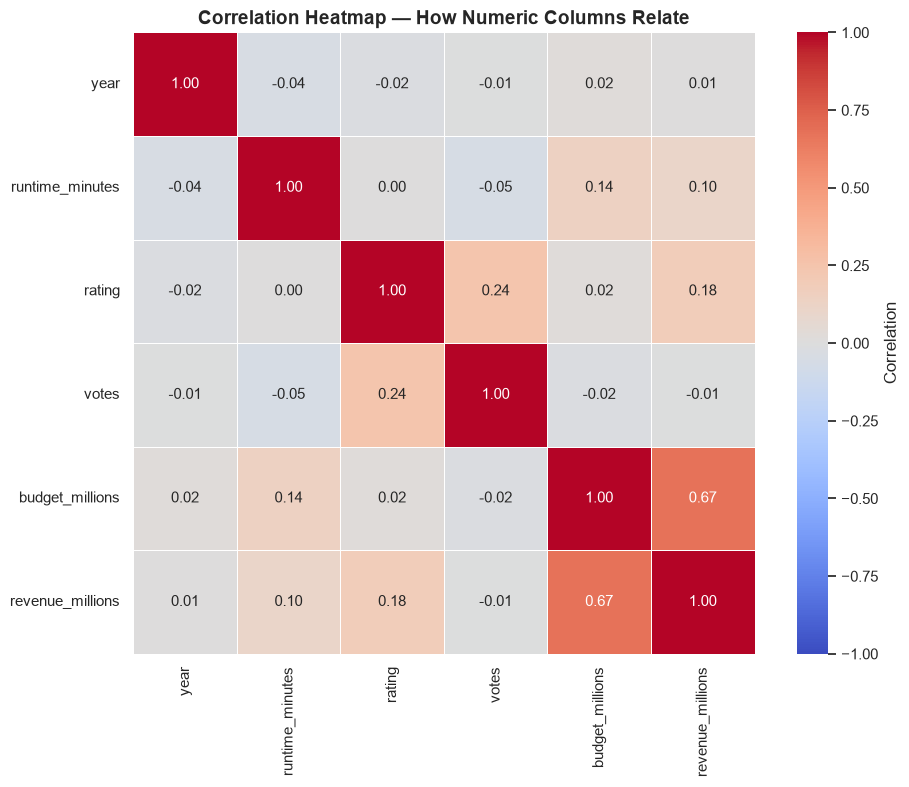

In [28]:
plt.figure(figsize=(10, 8))

# Heatmap — colours show correlation strength
# annot=True writes the correlation number in each cell
# cmap="coolwarm" uses blue for negative, red for positive
sns.heatmap(correlation_matrix,
            annot=True, fmt=".2f",
            cmap="coolwarm",
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={"label": "Correlation"})

plt.title("Correlation Heatmap — How Numeric Columns Relate",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Reading the heatmap:**
- The diagonal is always **1.00** (every column with itself)
- Dark **red** = strong positive correlation
- Dark **blue** = strong negative correlation
- Near **white/grey** = no relationship

Look for the off-diagonal red and blue cells — those are the interesting relationships.

---

## Step 13 — Analysis Question 9: Rating Spread per Genre (Boxplot)

A boxplot shows the median, range, and outliers for each group — perfect for comparing distributions across categories.

C:\Users\joan of arc\AppData\Local\Temp\ipykernel_16432\2065687423.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="genre", y="rating",


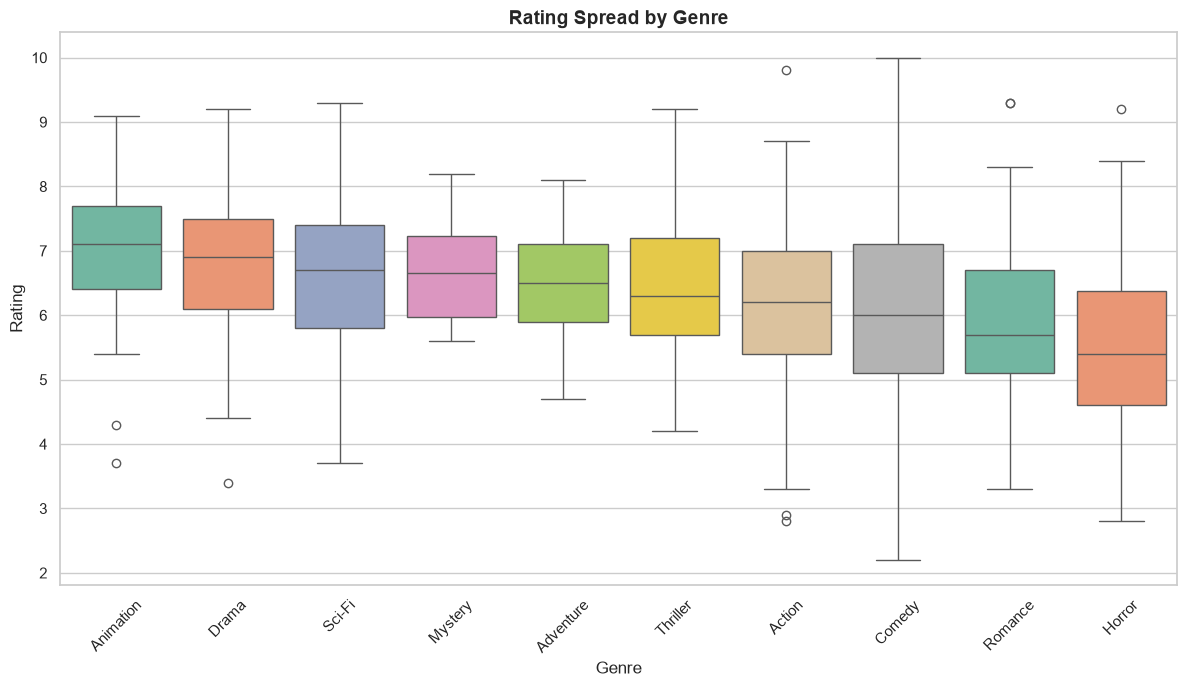

In [29]:
plt.figure(figsize=(12, 7))

# Get genres in order of median rating (highest first)
genre_order = df.groupby("genre")["rating"].median().sort_values(ascending=False).index

# Boxplot — one box per genre
sns.boxplot(data=df, x="genre", y="rating",
            order=genre_order,
            palette="Set2")

plt.title("Rating Spread by Genre", fontsize=14, fontweight="bold")
plt.xlabel("Genre")
plt.ylabel("Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**How to read a boxplot:**
- The **line in the middle of the box** = median
- The **box** = middle 50% of the data (between 25th and 75th percentile)
- The **whiskers** = full range of typical values
- **Dots outside the whiskers** = outliers (unusual values)

We can see which genres have tight ratings (consistent quality) and which have wide spreads (mix of great and terrible).

---

## Step 14 — Analysis Question 10: Revenue Distribution by Genre

In [30]:
# Total revenue per genre
revenue_by_genre = df.groupby("genre")["revenue_millions"].sum().sort_values(ascending=False)
print("Total revenue by genre (in millions $):")
print(revenue_by_genre.round(1))

Total revenue by genre (in millions $):
genre
Action       16023.8
Sci-Fi        9794.4
Drama         6444.9
Animation     4846.2
Thriller      4392.8
Comedy        4348.5
Adventure     2739.2
Horror        2295.7
Romance       2267.3
Mystery        481.7
Name: revenue_millions, dtype: float64


### 📊 Visualize as a pie chart

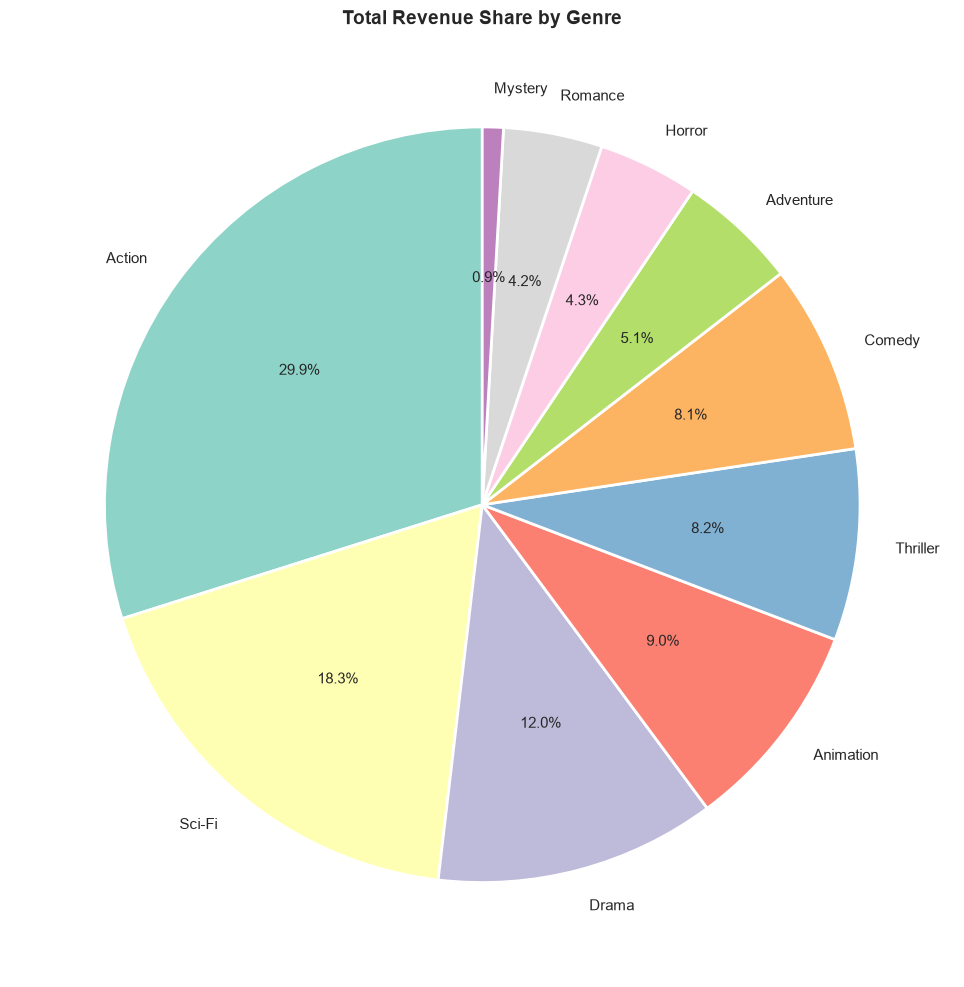

In [31]:
plt.figure(figsize=(10, 10))

# Pie chart — shows proportional split
colors_pie = sns.color_palette("Set3", n_colors=len(revenue_by_genre))

plt.pie(revenue_by_genre.values,
        labels=revenue_by_genre.index,
        autopct="%1.1f%%",     # show percentages with 1 decimal place
        colors=colors_pie,
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2})

plt.title("Total Revenue Share by Genre", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Tip:** Pie charts work best with 5–7 categories. With more, switch to a bar chart.

---

## Step 15 — Final Summary & Insights

Let's wrap up with the key findings from our analysis.

In [32]:
# Compute key summary statistics
total_movies = len(df)
total_revenue = df["revenue_millions"].sum()
avg_rating = df["rating"].mean()
top_genre_by_count = df["genre"].value_counts().idxmax()
top_genre_by_rating = df.groupby("genre")["rating"].mean().idxmax()
most_productive_director = df["director"].value_counts().idxmax()

# Build a nicely-formatted summary
print("=" * 60)
print("📊 IMDB MOVIE ANALYSIS — KEY FINDINGS")
print("=" * 60)
print(f"Total movies analyzed:           {total_movies:,}")
print(f"Total combined revenue:          ${total_revenue:,.1f} million")
print(f"Average rating:                  {avg_rating:.2f} / 10")
print(f"Most common genre:               {top_genre_by_count}")
print(f"Highest avg-rated genre:         {top_genre_by_rating}")
print(f"Most productive director:        {most_productive_director}")
print("=" * 60)

📊 IMDB MOVIE ANALYSIS — KEY FINDINGS
Total movies analyzed:           1,000
Total combined revenue:          $53,634.5 million
Average rating:                  6.32 / 10
Most common genre:               Action
Highest avg-rated genre:         Animation
Most productive director:        E. Silva


## ✅ Project Complete!

### What we did
1. ✅ Loaded a real-sized dataset (1000 movies)
2. ✅ Explored its shape and contents
3. ✅ Cleaned missing values
4. ✅ Answered 10 different analysis questions
5. ✅ Made 10 different types of visualizations
6. ✅ Wrote a final summary

### Tools we used
| Tool | What for |
|---|---|
| Pandas | Reading the CSV, exploring, filtering, grouping |
| NumPy | Numerical operations underneath Pandas |
| Matplotlib | Bar, line, scatter, histogram, pie charts |
| Seaborn | Boxplot, heatmap, prettier defaults |

### Where to go next
- Try this same workflow on a different dataset (Kaggle has thousands)
- Build the **Streamlit dashboard** (`../app/streamlit_app.py`) to share results interactively
- Add more questions: which director has the highest average rating? Has movie length increased over time?

**🎬 You've completed your first real data analytics project!**